# ME5413: Autonomous Mobile Robot  

## Homework 1: Perception  
-- by Mai Jingyang, GitHub @Whitbrunn, please contact maij@u.nus.edu for any questions.

## Task 1 Single-Object Tracking 


### 1.0 Install Packages
Special Note!!:
- Please make sure your numpy version is correct as follows.

In [ ]:
# !pip install numpy==1.26.0 # Pay Attention not 1.23, otherwise error!!!

# !pip install torch==2.1.0
# !pip install transformers==4.48.1
# !pip install timm==1.0.14
# !pip install matplotlib

### 1.1 Using Template Matching


Guide:
- Modify `seq_id` to select one sequence of data you want to do SOT.
- The TM tracking result file w.r.t each seq will be stored and updated in `results/1_template_matching/trackresults_TM_seq{seq_id}.txt`.
- Each line in each file represents the tracking bounding box w.r.t each frame, in (top_left_x, top_left_y, width, height) format.


Kindly Note:
- Feel free to run 
```
cd task1_tracking
python TP_demo.py
```
- Where you can see the real-time updating tracking illustrations of seq_X (press key 'q' to quit),
- And view the direct comparison between TM Tracking and Ground Truth.

In [1]:
import cv2
import sys
import os
import glob
from math import sqrt

def line2bbox(line):
    if line != "NaN":
        bbox = tuple([int(x) for x in line.split(",")]) # bbox: (x,y,width,height)
    else:
        bbox = line
    return bbox


In [2]:
seq_id = 1
seq_path = f"data/seq{str(seq_id)}"


img_path_lst = sorted(glob.glob(os.path.join(seq_path, "img", "*.jpg")))
with open(f"data/seq{str(seq_id)}/groundtruth.txt") as g_f:
    gtbbox_lst = g_f.read().splitlines()
with open(f"data/seq{str(seq_id)}/firsttrack.txt") as b0_f:
    b0_data = b0_f.readline()

# Initialize block box
bbox0 = line2bbox(b0_data) # bbox: (x,y,width,height)

In [4]:
def refine_bbox(bbox):
    bbox = list(bbox)
    if bbox[0] + bbox[2] > frame_w:
        bbox[2] = frame_w - bbox[0]
    if bbox[1] + bbox[3] > frame_h:
        bbox[3] = frame_h- bbox[1]
    bbox = tuple(bbox)
    return bbox

# Initialize tracker
tracker = cv2.TrackerCSRT_create()

# Initialize frame
frame = cv2.imread(img_path_lst[0])  # Read the image (same format as video frames)

if frame is None:
    print("Error! No Frame0!")
frame_h , frame_w, _ = frame.shape


# Initialize tracker with first frame and bounding box
ok = tracker.init(frame, bbox0)

# Store file
save_path = f"results/1_template_matching/trackresults_TM_seq{seq_id}.txt"
if os.path.exists(save_path):
        os.remove(save_path)
        print(f"Update {save_path}.")
save_f = open(save_path,"a",encoding="utf-8")
save_f.write(str(bbox0).strip("()").replace(" ","")+"\n")

for id, img_path in enumerate(img_path_lst[1:]): # start from No.2 img
    # Read a new frame
    
    frame = cv2.imread(img_path)
    

    # Update tracker
    ok, bbox = tracker.update(frame)

    bbox = refine_bbox(bbox)
    save_f.write(str(bbox).strip("()").replace(" ","")+"\n")

save_f.close()


### 1.2 Using Object Detection algorithm and Association


Guide:
- Modify `seq_id` to select one sequence of data you want to do SOT.
- The ODA tracking result file w.r.t each seq will be stored and updated in `results/2_objectdetection_withassociation/trackresults_ODA_seq{seq_id}.txt`.
- Each line in each file represents the tracking bounding box w.r.t each frame, in (top_left_x, top_left_y, width, height) format.


Special Note!!:
- Recommend to run directly
```
cd task1_tracking
python Detr_demo.py
```
instead of this jupyter notebook section 1.2 (otherwise unexpected results ouput),
- Where you can easily get the tracking results in folder `task1_tracking/results/2_objectdetection_withassociation`,
- And see the real-time updating tracking illustrations of seq_X (press key 'q' to quit).
- Association part is adapted from https://github.com/Sharpiless/Yolov5-deepsort-inference.

In [ ]:
%reset -f

In [42]:
from transformers import AutoImageProcessor, DetrForObjectDetection
image_processor = AutoImageProcessor.from_pretrained("./detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("./detr-resnet-50")

Some weights of the model checkpoint at ./detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [45]:
from AIDetector_pytorch import Detector
import cv2
import glob
import os
from PIL import Image

def line2bbox(line):
    if line != "NaN":
        bbox = tuple([int(x) for x in line.split(",")]) # bbox: (x,y,width,height)
    else:
        bbox = line
    return bbox

def IOU_succ(bbox1, bbox2):
    bx0, by0, bxr, byr = bbox1
    gx0, gy0, gxr,gyr = bbox2
    
    xmin = max(bx0, gx0)
    ymin = max(by0, gy0)

    xmax = min(bxr, gxr)
    ymax = min(byr, gyr)

    IOU_w = max(0, xmax-xmin)
    IOU_h = max(0, ymax-ymin)

    IOU_a = IOU_w * IOU_h

    b1_a = (bbox1[2]-bbox1[0]) * (bbox1[3]-bbox1[1])
    b2_a = (bbox2[2]-bbox2[0]) * (bbox2[3]-bbox2[1])
    succ = IOU_a/(b1_a+b2_a-IOU_a)

    return succ

seq_id =2
seq_path = f"data/seq{str(seq_id)}"


img_path_lst = sorted(glob.glob(os.path.join(seq_path, "img", "*.jpg")))
with open(f"data/seq{str(seq_id)}/groundtruth.txt") as g_f:
    gtbbox_lst = g_f.read().splitlines()
with open(f"data/seq{str(seq_id)}/firsttrack.txt") as b0_f:
    b0_data = b0_f.readline()

# Initialize block box
bbox0 = line2bbox(b0_data) # bbox: (x,y,width,height)

track_id_lst = [1,1,1,4,1]
track_str = str(track_id_lst[seq_id-1])
det = Detector()

# Store file
save_f = open(f"results/2_objectdetection_withassociation/trackresults_ODA_seq{seq_id}.txt","a",encoding="utf-8")

for img_path in img_path_lst:
    
    im = Image.open(img_path)
    if im is None:
        break
    
    result = det.feedCap(im)
    bbox_info = result['bbox_dic']
    # print(bbox_info)


    flag = 0
    if bbox_info != {}:
        if track_str in bbox_info:
            flag = 1

    if flag:
        tar_bbox = bbox_info[track_str]
        bbox_in_xywh = (tar_bbox[0], tar_bbox[1], tar_bbox[2]-tar_bbox[0],tar_bbox[3]-tar_bbox[1])
        save_f.write(str(bbox_in_xywh).strip("()").replace(" ","")+"\n")
    else:
        save_f.write("NaN\n")

save_f.close()    

### 1.3 Evaluation of the TM and ODA Method

Evaluate the performance of the Single object tracking algorithm for both **Template Matching** and **Detection Algorithm with Association**. Using the **Success** and **Precision** metrics. 

$$
Success = \frac{BB_{tr} \cap BB_{gt}}{BB_{tr} \cup BB_{gt}} ;    
Precision = || C_{tr} - C_{gt} ||_2
$$

In [4]:
%reset -f

In [5]:
from math import sqrt

def precision_count(bbox, gtbbox, prec_thed):
    prec_ct = 0
    x0 = bbox[0]
    y0 = bbox[1]
    width = bbox[2]
    height = bbox[3]

    b_cent = (x0 + width/2, y0 + height/2)
    truth_cent = (gtbbox[0] + gtbbox[2]/2, gtbbox[1] + gtbbox[3]/2)
    
    dis = sqrt((b_cent[0]-truth_cent[0])**2 + (b_cent[1]-truth_cent[1])**2 )

    if dis <= prec_thed:
        prec_ct = 1

    return prec_ct

def success_count(bbox, gtbbox, succ_thed):
    succ_ct = 0
    bx0, by0, bw, bh = bbox
    bxr = bx0 + bw
    byr = by0 + bh

    gx0, gy0, gw, gh = gtbbox
    gxr = gx0 + gw
    gyr = gy0 + gh

    b_a = bw*bh
    g_a = gw*gh

    IOU_w = 0
    IOU_h = 0

    xmin = max(bx0, gx0)
    ymin = max(by0, gy0)

    xmax = min(bxr, gxr)
    ymax = min(byr, gyr)

    IOU_w = max(0, xmax-xmin)
    IOU_h = max(0, ymax-ymin)


    IOU_a = IOU_w * IOU_h

    succ = IOU_a/(b_a+g_a-IOU_a)

    if succ>=succ_thed:
        succ_ct = 1
    return succ_ct

In [7]:
seq_id_lst = [1,2,3,4,5]

for seq_id in seq_id_lst:
    with open(f"data/seq{str(seq_id)}/groundtruth.txt") as g_f:
        gtbbox_lst = g_f.read().splitlines()

    with open(f"results/1_template_matching/trackresults_TM_seq{seq_id}.txt") as f1:
        bbox_tm_lst = f1.read().splitlines()
    with open(f"results/2_objectdetection_withassociation/trackresults_ODA_seq{seq_id}.txt") as f2:
        bbox_oda_lst = f2.read().splitlines()

    bbox_lst_all = [bbox_tm_lst, bbox_oda_lst]
    method = ["TM", "ODA"]

    if len(bbox_tm_lst) == len(bbox_oda_lst) == len(gtbbox_lst):
        print(f"Seq{seq_id},")
        for method_id, bbox_lst in enumerate(bbox_lst_all):
            ct = 0
            prec_ct_all = 0
            succ_ct_all = 0
            for id in range(len(gtbbox_lst)-1):
                gt_line = gtbbox_lst[id+1]
                gtbbox = tuple([ int(x) for x in gt_line.split(',')])

                bbline = bbox_lst[id+1]
                if bbline != "NaN":
                    bbox = tuple([ int(x) for x in bbline.split(',')])

                    prec_thed = 20
                    prec_ct = precision_count(bbox, gtbbox, prec_thed)
                    prec_ct_all +=prec_ct

                    succ_thed = 0.5
                    succ_ct = success_count(bbox, gtbbox, succ_thed)
                    succ_ct_all += succ_ct

                    ct+=1
                else:
                    pass
            

            prec = prec_ct_all/ct
            succ = succ_ct_all/ct
            print(f"{method[method_id]}: precion={prec}, succuss:{succ}.")
    else:
        print(f"Check!{len(bbox_tm_lst)} == {len(bbox_oda_lst)} == {len(gtbbox_lst)}")



Seq1,
TM: precion=1.0, succuss:1.0.
ODA: precion=0.9712230215827338, succuss:0.9712230215827338.
Seq2,
TM: precion=0.8993288590604027, succuss:0.8322147651006712.
ODA: precion=1.0, succuss:0.9090909090909091.
Seq3,
TM: precion=0.4899328859060403, succuss:1.0.
ODA: precion=0.3358208955223881, succuss:0.6194029850746269.
Seq4,
TM: precion=0.06040268456375839, succuss:0.06040268456375839.
ODA: precion=0.8714285714285714, succuss:0.9357142857142857.
Seq5,
TM: precion=0.7315436241610739, succuss:0.738255033557047.
ODA: precion=0.31724137931034485, succuss:0.9379310344827586.


### 1.4 Visualisation of the Tracking Results of the TM & ODA Method


Guide:
- You should modify `img_file` to select one image you want to display,
- And modify `method`="TM" or "ODA" to select which method you want to use.
- The above two info. will be shown on the left top of the display image.

In [8]:
import matplotlib.pyplot as plt
import cv2

def line2bbox(line):
    if line != "NaN":
        bbox = tuple([int(x) for x in line.split(",")]) # bbox: (x,y,width,height)
    else:
        bbox = line
    return bbox


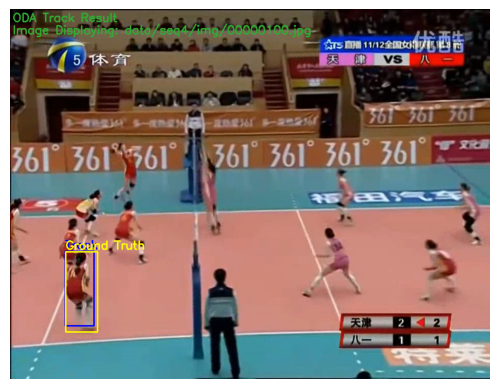

Tracking Results for this image using Template matching is (in xmin, ymin, width, height): (203, 361, 49, 143)
Tracking Results for this image using Object Detection is(in xmin, ymin, width, height): (107, 471, 56, 145)


In [9]:
## put your code here: This function should be able to visualise this image and their tracking results
# Choose one image to display
img_file = 'data/seq4/img/00000100.jpg'

# Choose the Detect Method:
method = "ODA" # Or "TM"

frame = cv2.imread(img_file)
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

seq_str = img_file.split('/')[1]
img_id = int(img_file.split('/')[-1].replace(".jpg", ""))-1
# print(img_id)

with open(f"data/{seq_str}/groundtruth.txt") as g_f:
    gtbbox_lst = g_f.read().splitlines()

with open(f"results/1_template_matching/trackresults_TM_{seq_str}.txt") as f1:
    bbox_tm_lst = f1.read().splitlines()

with open(f"results/2_objectdetection_withassociation/trackresults_ODA_{seq_str}.txt") as f2:
    bbox_oda_lst = f2.read().splitlines()



eva_gbbox = line2bbox(gtbbox_lst[img_id])
eva_tm_bbox = line2bbox(bbox_tm_lst[img_id])
eva_oda_bbox = line2bbox(bbox_oda_lst[img_id])


fontscale = min(round(frame.shape[1]/800,2), 0.75)



flag = 1

if method == "TM":
    bbox = eva_tm_bbox
elif method == "ODA":
    if eva_oda_bbox != "NaN":
        bbox = eva_oda_bbox
    else:
        flag = 0
        print("No ODA Tracks in this frame, please choose another image for safe tracking.")

cv2.putText(frame, f"{method} Track Result", (5,24), cv2.FONT_HERSHEY_SIMPLEX, fontscale, (50,170,50),2)
cv2.putText(frame, f"Image Displaying: {img_file}", (5,48), cv2.FONT_HERSHEY_SIMPLEX, fontscale, (50,170,50),2)

if flag:
    p1 = (int(bbox[0]), int(bbox[1]))
    p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
    cv2.rectangle(frame, p1, p2, (0,0,255), 2, 1) # Draw a detected block
    cv2.putText(frame, "Track", (p1[0], p1[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.75,(0,0,255),2)
else:
    cv2.putText(frame, "No ODA Tracks in this frame, please select again.", (5,72), cv2.FONT_HERSHEY_SIMPLEX, fontscale, (255,0,0),2)

gp1 = (int(eva_gbbox[0]), int(eva_gbbox[1]))
gp2 = (int(eva_gbbox[0] + eva_gbbox[2]), int(eva_gbbox[1] + eva_gbbox[3]))
cv2.rectangle(frame, gp1, gp2, (255,255,0), 2, 1) # Draw a ground truth block
cv2.putText(frame, "Ground Truth", (gp1[0], gp1[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.75,(255,255,0),2)
 
plt.imshow(frame)
plt.axis("off")
plt.show()



print(f'Tracking Results for this image using Template matching is (in xmin, ymin, width, height): {eva_tm_bbox}')
## show image of visualised result of ground truth and track results

print(f'Tracking Results for this image using Object Detection is(in xmin, ymin, width, height): {eva_oda_bbox}')
## show image of visualised result of ground truth and track results


### 1.5 Improved Method: Yolov5-DeepSort

#### 1.5.1 Implementation

Guide:
- Run 
```
cd task1_tracking
python Improved_demo.py
```
- Where you can easily get the tracking results in folder `task1_tracking/results/3_improved`,
- And see the real-time updating tracking illustrations of seq_X (press key 'q' to quit).
- Adapted from https://github.com/Sharpiless/Yolov5-deepsort-inference.

#### 1.5.2 Evaluation

Guide:
- Run the following blocks.

In [9]:
%reset -f

In [10]:
from math import sqrt

def precision_count(bbox, gtbbox, prec_thed):
    prec_ct = 0
    x0 = bbox[0]
    y0 = bbox[1]
    width = bbox[2]
    height = bbox[3]

    b_cent = (x0 + width/2, y0 + height/2)
    truth_cent = (gtbbox[0] + gtbbox[2]/2, gtbbox[1] + gtbbox[3]/2)
    
    dis = sqrt((b_cent[0]-truth_cent[0])**2 + (b_cent[1]-truth_cent[1])**2 )

    if dis <= prec_thed:
        prec_ct = 1

    return prec_ct

def success_count(bbox, gtbbox, succ_thed):
    succ_ct = 0
    bx0, by0, bw, bh = bbox
    bxr = bx0 + bw
    byr = by0 + bh

    gx0, gy0, gw, gh = gtbbox
    gxr = gx0 + gw
    gyr = gy0 + gh

    b_a = bw*bh
    g_a = gw*gh

    IOU_w = 0
    IOU_h = 0

    xmin = max(bx0, gx0)
    ymin = max(by0, gy0)

    xmax = min(bxr, gxr)
    ymax = min(byr, gyr)

    IOU_w = max(0, xmax-xmin)
    IOU_h = max(0, ymax-ymin)


    IOU_a = IOU_w * IOU_h

    succ = IOU_a/(b_a+g_a-IOU_a)

    if succ>=succ_thed:
        succ_ct = 1
    return succ_ct

In [11]:
# Choose one seq id!!
seq_id_lst = [1,2,3,4,5]

for seq_id in seq_id_lst:
    with open(f"data/seq{str(seq_id)}/groundtruth.txt") as g_f:
        gtbbox_lst = g_f.read().splitlines()

    with open(f"results/3_improved/trackresults_improved_seq{seq_id}.txt") as f1:
        bbox_ys_lst = f1.read().splitlines()

    bbox_lst = bbox_ys_lst

    method = "Yolov5-Deepsort"

    if len(bbox_lst) == len(gtbbox_lst):
        print(f"Seq{seq_id},")
        
        ct = 0
        prec_ct_all = 0
        succ_ct_all = 0
        for id in range(len(gtbbox_lst)-1):
            gt_line = gtbbox_lst[id+1]
            gtbbox = tuple([ int(x) for x in gt_line.split(',')])

            bbline = bbox_lst[id+1]
            if bbline != "NaN":
                bbox = tuple([ int(x) for x in bbline.split(',')])

                prec_thed = 20
                prec_ct = precision_count(bbox, gtbbox, prec_thed)
                prec_ct_all +=prec_ct

                succ_thed = 0.5
                succ_ct = success_count(bbox, gtbbox, succ_thed)
                succ_ct_all += succ_ct

                ct+=1
            else:
                pass
        

        prec = prec_ct_all/ct
        succ = succ_ct_all/ct
        print(f"{method}: precion={prec}, succuss:{succ}.")
    else:
        print(f"Check!{len(bbox_lst)} == {len(gtbbox_lst)}")



Seq1,
Yolov5-Deepsort: precion=1.0, succuss:1.0.
Seq2,
Yolov5-Deepsort: precion=0.991304347826087, succuss:0.9130434782608695.
Seq3,
Yolov5-Deepsort: precion=0.3387096774193548, succuss:0.6693548387096774.
Seq4,
Yolov5-Deepsort: precion=0.9230769230769231, succuss:0.9692307692307692.
Seq5,
Yolov5-Deepsort: precion=0.5422535211267606, succuss:0.9647887323943662.


#### 1.5.3 Visulisation

Guide:
- You should modify `img_file` to select one image you want to display,
- The above info. and `method` will be shown on the left top of the display image.

In [16]:
import matplotlib.pyplot as plt
import cv2

def line2bbox(line):
    if line != "NaN":
        bbox = tuple([int(x) for x in line.split(",")]) # bbox: (x,y,width,height)
    else:
        bbox = line
    return bbox

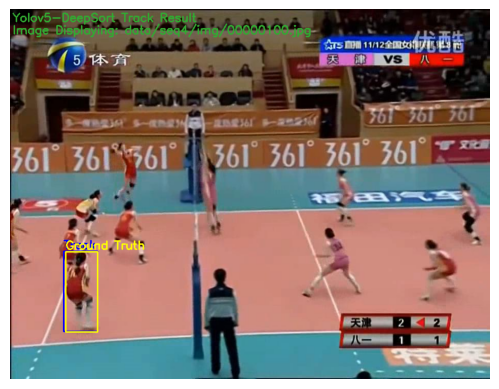

Tracking Results for this image using Improved Method is (in xmin, ymin, width, height): (104, 471, 66, 156)


In [17]:
## put your code here: This function should be able to visualise this image and their tracking results
# Choose one image to display
img_file = 'data/seq4/img/00000100.jpg'

# Choose the Detect Method:
method = "Yolov5-DeepSort"

frame = cv2.imread(img_file)
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

seq_str = img_file.split('/')[1]
img_id = int(img_file.split('/')[-1].replace(".jpg", ""))-1
# print(img_id)

with open(f"data/{seq_str}/groundtruth.txt") as g_f:
    gtbbox_lst = g_f.read().splitlines()

with open(f"results/3_improved/trackresults_improved_{seq_str}.txt") as f1:
    bbox_ys_lst = f1.read().splitlines()




eva_gbbox = line2bbox(gtbbox_lst[img_id])
eva_ys_bbox = line2bbox(bbox_ys_lst[img_id])


fontscale = min(round(frame.shape[1]/800,2), 0.75)



flag = 1

if eva_ys_bbox != "NaN":
    bbox = eva_ys_bbox
else:
    flag = 0
    print("No Yolov5-DeepSort Tracks in this frame, please choose another image for safe tracking.")

cv2.putText(frame, f"{method} Track Result", (5,24), cv2.FONT_HERSHEY_SIMPLEX, fontscale, (50,170,50),2)
cv2.putText(frame, f"Image Displaying: {img_file}", (5,48), cv2.FONT_HERSHEY_SIMPLEX, fontscale, (50,170,50),2)

if flag:
    p1 = (int(bbox[0]), int(bbox[1]))
    p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
    cv2.rectangle(frame, p1, p2, (0,0,255), 2, 1) # Draw a detected block
    cv2.putText(frame, "Track", (p1[0], p1[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.75,(0,0,255),2)
else:
    cv2.putText(frame, "No ODA Tracks in this frame, please select again.", (5,72), cv2.FONT_HERSHEY_SIMPLEX, fontscale, (255,0,0),2)

gp1 = (int(eva_gbbox[0]), int(eva_gbbox[1]))
gp2 = (int(eva_gbbox[0] + eva_gbbox[2]), int(eva_gbbox[1] + eva_gbbox[3]))
cv2.rectangle(frame, gp1, gp2, (255,255,0), 2, 1) # Draw a ground truth block
cv2.putText(frame, "Ground Truth", (gp1[0], gp1[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.75,(255,255,0),2)
 
plt.imshow(frame)
plt.axis("off")
plt.show()

print(f'Tracking Results for this image using Improved Method is (in xmin, ymin, width, height): {eva_ys_bbox}') 
## show image of visualised result of ground truth and track results